In [1]:
#DATA COLLECTION
import yfinance as yf
import pandas as pd

In [2]:
tickers=['TCS.NS','INFY.NS','WIPRO.NS', #IT INDUSTRY
         'HDFCBANK.NS','ICICIBANK.NS','SBIN.NS',  #BANKS
         'ITC.NS','HINDUNILVR.NS','NESTLEIND.NS'  #FMCG
         ]

In [3]:
data=yf.download(tickers,period='5y')

[*********************100%***********************]  9 of 9 completed


In [4]:
print(data.head())

Price            Close                                                      \
Ticker     HDFCBANK.NS HINDUNILVR.NS ICICIBANK.NS      INFY.NS      ITC.NS   
Date                                                                         
2021-03-30  735.813416   2205.903564   572.043091  1219.507690  168.660339   
2021-03-31  707.374573   2236.020752   562.999878  1204.322266  171.765488   
2021-04-01  704.106689   2206.225342   574.896362  1219.419800  172.983948   
2021-04-05  686.512878   2182.407471   552.505859  1241.163696  167.088135   
2021-04-06  682.084839   2214.686035   547.331482  1242.175903  167.166733   

Price                                                               High  ...  \
Ticker     NESTLEIND.NS     SBIN.NS       TCS.NS    WIPRO.NS HDFCBANK.NS  ...   
Date                                                                      ...   
2021-03-30   811.438110  332.916168  2776.608398  193.141129  740.004714  ...   
2021-03-31   811.447449  336.145630  2793.574463  1

In [5]:
#DATA CLEANING
data=data['Close']

In [6]:
data=data.dropna()

In [7]:
print("Shape:",data.shape)
print("Missing values:",data.isnull().sum().sum())
print(data.head())

Shape: (1237, 9)
Missing values: 0
Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS      INFY.NS      ITC.NS  \
Date                                                                            
2021-03-30   735.813416    2205.903564    572.043091  1219.507690  168.660339   
2021-03-31   707.374573    2236.020752    562.999878  1204.322266  171.765488   
2021-04-01   704.106689    2206.225342    574.896362  1219.419800  172.983948   
2021-04-05   686.512878    2182.407471    552.505859  1241.163696  167.088135   
2021-04-06   682.084839    2214.686035    547.331482  1242.175903  167.166733   

Ticker      NESTLEIND.NS     SBIN.NS       TCS.NS    WIPRO.NS  
Date                                                           
2021-03-30    811.438110  332.916168  2776.608398  193.141129  
2021-03-31    811.447449  336.145630  2793.574463  191.316422  
2021-04-01    807.568665  342.004883  2782.278076  192.355820  
2021-04-05    797.991272  326.226440  2847.242432  196.536453  
2021-04-06   

In [8]:
data.to_csv("data/nifty_data.csv")

In [9]:
sector_map={'TCS.NS':'IT','INFY.NS':'IT','WIPRO':'IT','HDFCBANK.NS':'Banking','ICICIBANK.NS':'Banking','SBIN.NS':'Banking','ITC.NS':'FMCG','HINDUNILVR.NS':'FMCG','NESTLEIND.NS':'FMCG'}

In [ ]:
#DATA ANALYSIS
returns=data.pct_change().dropna()
print(returns.head())

Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS    ITC.NS  \
Date                                                                       
2021-03-31    -0.038650       0.013653     -0.015809 -0.012452  0.018411   
2021-04-01    -0.004620      -0.013325      0.021131  0.012536  0.007094   
2021-04-05    -0.024987      -0.010796     -0.038947  0.017831 -0.034083   
2021-04-06    -0.006450       0.014790     -0.009365  0.000816  0.000470   
2021-04-07     0.004826      -0.001267      0.020763  0.013571  0.005408   

Ticker      NESTLEIND.NS   SBIN.NS    TCS.NS  WIPRO.NS  
Date                                                    
2021-03-31      0.000012  0.009701  0.006110 -0.009448  
2021-04-01     -0.004780  0.017431 -0.004044  0.005433  
2021-04-05     -0.011860 -0.046135  0.023349  0.021734  
2021-04-06      0.011916 -0.008485  0.007965  0.003996  
2021-04-07      0.019210  0.022821  0.002052  0.025401  


In [11]:
mean_returns=returns.mean()
print(mean_returns.head())

Ticker
HDFCBANK.NS      0.000082
HINDUNILVR.NS    0.000022
ICICIBANK.NS     0.000690
INFY.NS          0.000138
ITC.NS           0.000512
dtype: float64


In [12]:
volatility=returns.std()
print(volatility.head())

Ticker
HDFCBANK.NS      0.013131
HINDUNILVR.NS    0.012605
ICICIBANK.NS     0.013134
INFY.NS          0.015304
ITC.NS           0.012639
dtype: float64


In [13]:
rolling_vol=returns.rolling(21).std()
print(rolling_vol.head())  #The first 21 days will have NAN values because a 21 day window is required to calculate rolling volatility.

Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  INFY.NS  ITC.NS  \
Date                                                                    
2021-03-31          NaN            NaN           NaN      NaN     NaN   
2021-04-01          NaN            NaN           NaN      NaN     NaN   
2021-04-05          NaN            NaN           NaN      NaN     NaN   
2021-04-06          NaN            NaN           NaN      NaN     NaN   
2021-04-07          NaN            NaN           NaN      NaN     NaN   

Ticker      NESTLEIND.NS  SBIN.NS  TCS.NS  WIPRO.NS  
Date                                                 
2021-03-31           NaN      NaN     NaN       NaN  
2021-04-01           NaN      NaN     NaN       NaN  
2021-04-05           NaN      NaN     NaN       NaN  
2021-04-06           NaN      NaN     NaN       NaN  
2021-04-07           NaN      NaN     NaN       NaN  


In [14]:
correlation=returns.corr()
print(correlation)

Ticker         HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS    ITC.NS  \
Ticker                                                                        
HDFCBANK.NS       1.000000       0.198911      0.513050  0.253758  0.221584   
HINDUNILVR.NS     0.198911       1.000000      0.173303  0.194170  0.316441   
ICICIBANK.NS      0.513050       0.173303      1.000000  0.244505  0.272745   
INFY.NS           0.253758       0.194170      0.244505  1.000000  0.164688   
ITC.NS            0.221584       0.316441      0.272745  0.164688  1.000000   
NESTLEIND.NS      0.170620       0.498374      0.166363  0.163864  0.285198   
SBIN.NS           0.413906       0.117043      0.539351  0.189702  0.291211   
TCS.NS            0.229141       0.223528      0.215850  0.708242  0.148718   
WIPRO.NS          0.276675       0.131288      0.253650  0.630791  0.178856   

Ticker         NESTLEIND.NS   SBIN.NS    TCS.NS  WIPRO.NS  
Ticker                                                     
HDFCBANK.N

In [15]:
sector_returns=returns.T.groupby(sector_map).mean().T #It gives the returns based on sector
print(sector_returns.head())

Ticker       Banking      FMCG        IT
Date                                    
2021-03-31 -0.014919  0.010692 -0.003171
2021-04-01  0.011314 -0.003671  0.004246
2021-04-05 -0.036690 -0.018913  0.020590
2021-04-06 -0.008100  0.009059  0.004391
2021-04-07  0.016137  0.007784  0.007812


In [16]:
#VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

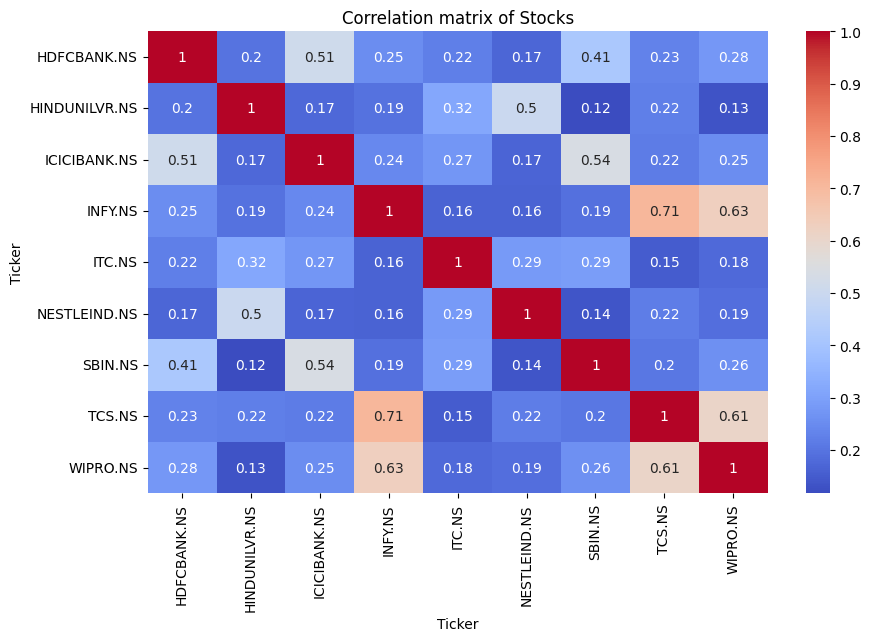

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation matrix of Stocks")
plt.show()


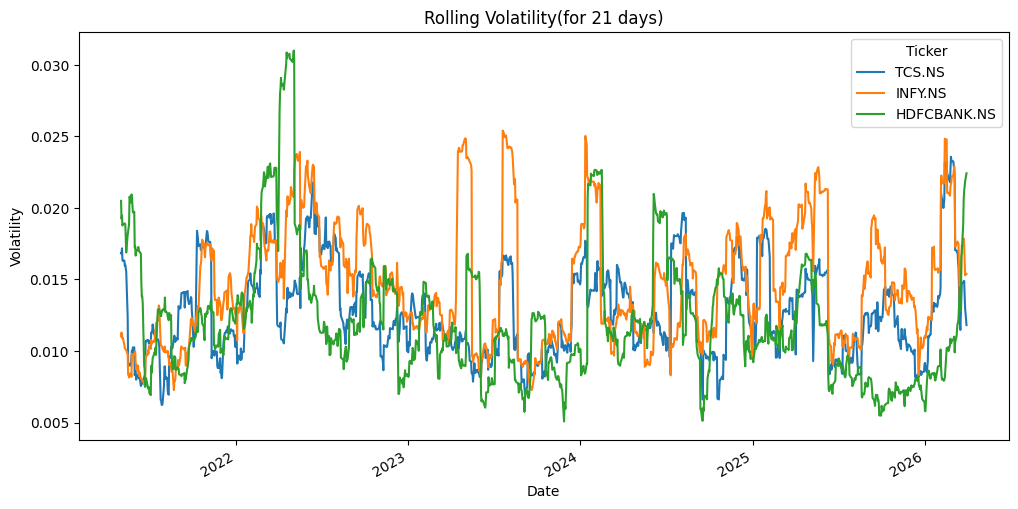

In [18]:
rolling_vol[['TCS.NS','INFY.NS','HDFCBANK.NS']].plot(figsize=(12,6))  #For selected stocks
plt.title("Rolling Volatility(for 21 days)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()  #This plot shows volatility clustering.

In [19]:
sector_vol=returns.T.groupby(sector_map).std().T
sector_vol_mean=sector_vol.mean()

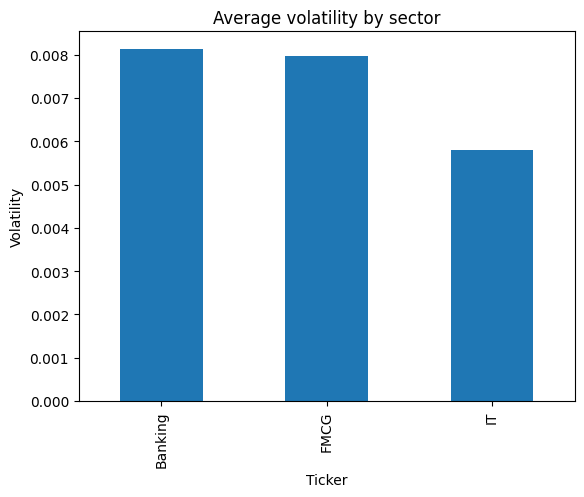

In [ ]:
sector_vol_mean.plot(kind='bar')
plt.title("Average volatility by sector")
plt.ylabel("Volatility")
plt.show() #This analysis indicates that Banking sector has the highest volatility among all three sectors,suggesting higher risk during the period.

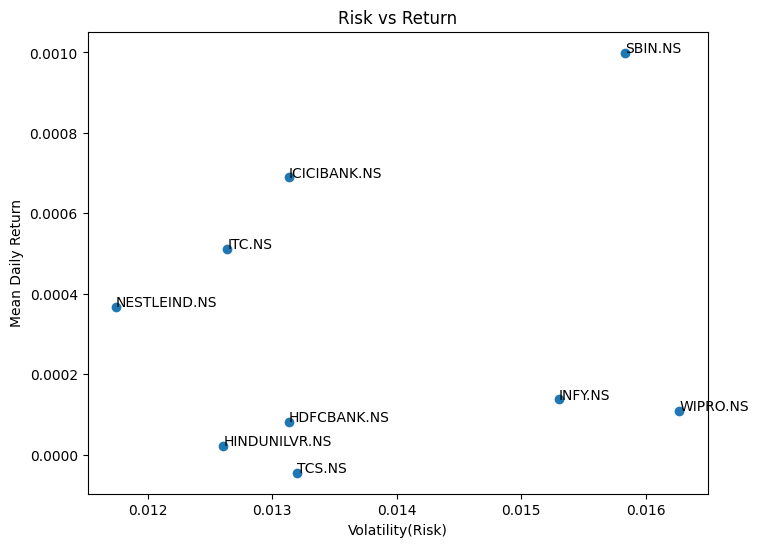

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(volatility,mean_returns)
for stock in mean_returns.index:
    plt.text(volatility[stock],mean_returns[stock],stock)
plt.xlabel("Volatility(Risk)")
plt.ylabel("Mean Daily Return")
plt.title("Risk vs Return")
plt.show() #Stocks located in the upper left offer better risk-adjusted returns meanwhile those in lower right indicate inefficient risk-return trade-offs

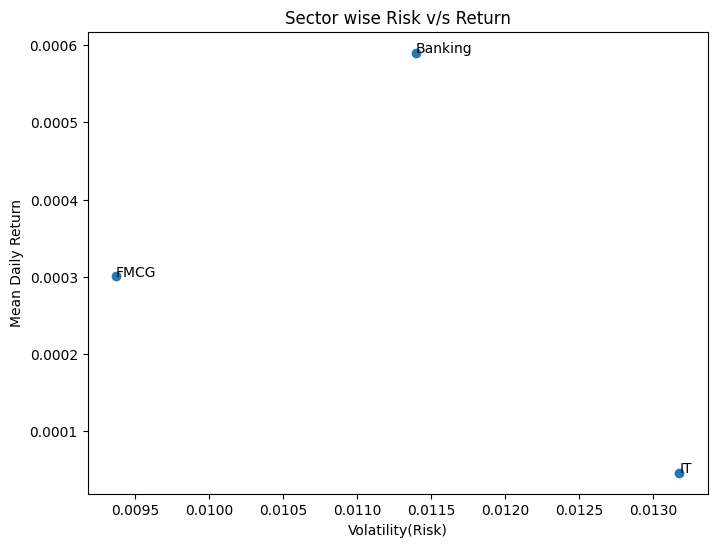

In [22]:
sector_return_mean=sector_returns.mean()
sector_vol1=sector_returns.std()
plt.figure(figsize=(8,6))
plt.scatter(sector_vol1,sector_return_mean)
for sector in sector_return_mean.index:
    plt.text(sector_vol1[sector],sector_return_mean[sector],sector)
plt.xlabel("Volatility(Risk)")
plt.ylabel("Mean Daily Return")
plt.title("Sector wise Risk v/s Return")
plt.show()

In [23]:
#Data Storage and SQL Analysis
import sqlite3
conn=sqlite3.connect("nifty_analysis.db")
returns.to_sql("returns",conn,if_exists="replace")

1236

In [24]:
query="SELECT * from returns LIMIT 5"
result=pd.read_sql(query,conn)
result

,Date,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,NESTLEIND.NS,SBIN.NS,TCS.NS,WIPRO.NS
0,2021-03-31 00:00:00,-0.038650,0.013653,-0.015809,-0.012452,0.018411,0.000012,0.009701,0.006110,-0.009448
1,2021-04-01 00:00:00,-0.004620,-0.013325,0.021131,0.012536,0.007094,-0.004780,0.017431,-0.004044,0.005433
2,2021-04-05 00:00:00,-0.024987,-0.010796,-0.038947,0.017831,-0.034083,-0.011860,-0.046135,0.023349,0.021734
3,2021-04-06 00:00:00,-0.006450,0.014790,-0.009365,0.000816,0.000470,0.011916,-0.008485,0.007965,0.003996
4,2021-04-07 00:00:00,0.004826,-0.001267,0.020763,0.013571,0.005408,0.019210,0.022821,0.002052,0.025401


In [25]:
vol_df=volatility.reset_index()
vol_df.columns=['Stock','Volatility']
vol_df.to_sql("volatility",conn,if_exists="replace",index=False)
query="""SELECT * from volatility order by Volatility DESC LIMIT 1"""
print(pd.read_sql(query,conn))# This analysis shows that WIPRO.NS stock has the highest volatility of all the stocks

      Stock  Volatility
0  WIPRO.NS     0.01627


In [26]:
mean_df=mean_returns.reset_index()
mean_df.columns=['Stock','MeanReturn']
mean_df.to_sql("mean_returns",conn,if_exists="replace",index=False)
query="""SELECT * from  mean_returns order by MeanReturn DESC"""
print(pd.read_sql(query,conn)) #This analysis calculates the mean return of each stock

           Stock  MeanReturn
0        SBIN.NS    0.000999
1   ICICIBANK.NS    0.000690
2         ITC.NS    0.000512
3   NESTLEIND.NS    0.000368
4        INFY.NS    0.000138
5       WIPRO.NS    0.000109
6    HDFCBANK.NS    0.000082
7  HINDUNILVR.NS    0.000022
8         TCS.NS   -0.000045


In [27]:
#  Insights 
#       Different methods of volatility estimation yield varying insights, emphasizing the need of careful interpretation
#       Banking sector is by-far the best sector in providing best returns albeit a higher risk is involved
#       IT sector is the most inefficient sector out of the bunch as it shows weaker risk-adjusted performance compared to other sectors.    
   

In [28]:
returns.to_csv("data/returns.csv")

In [29]:
mean_df.to_csv("data/mean_returns.csv",index=False)

In [30]:
vol_df.to_csv("data/volatilty.csv",index=False)

In [31]:
sector_summary=pd.DataFrame({"Sector":sector_return_mean.index,"MeanReturn":sector_return_mean.values,"Volatility":sector_vol1.values})
sector_summary.to_csv("data/sector_summary.csv",index=False)

In [32]:
with pd.ExcelWriter("data_analysis.xlsx") as writer:
    returns.to_excel(writer,sheet_name="Returns")
    mean_df.to_excel(writer,sheet_name="Mean_Returns",index=False)
    vol_df.to_excel(writer,sheet_name="Volatility",index=False)
    sector_summary.to_excel(writer,sheet_name="Sector_Summary",index=False)